In [77]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, r2_score)

In [78]:
print(os.getcwd())

c:\Users\DELL\m5-l5a-regression-eval-Jumana-ML-2


In [79]:
file_path = os.path.join('data', 'telecom_churn.csv')
df = pd.read_csv(file_path)
df = df.copy()

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1500 non-null   str    
 1   gender             1500 non-null   str    
 2   senior_citizen     1500 non-null   int64  
 3   tenure             1500 non-null   int64  
 4   monthly_charges    1500 non-null   float64
 5   total_charges      1500 non-null   float64
 6   contract_type      1500 non-null   str    
 7   internet_service   1500 non-null   str    
 8   num_support_calls  1500 non-null   int64  
 9   payment_method     1500 non-null   str    
 10  has_partner        1500 non-null   int64  
 11  has_dependents     1500 non-null   int64  
 12  churned            1500 non-null   int64  
dtypes: float64(2), int64(6), str(5)
memory usage: 152.5 KB


In [81]:
X = df.drop(columns=['churned', 'customer_id'])
y = df['churned']

In [82]:
print(columns := X.columns)

Index(['gender', 'senior_citizen', 'tenure', 'monthly_charges',
       'total_charges', 'contract_type', 'internet_service',
       'num_support_calls', 'payment_method', 'has_partner', 'has_dependents'],
      dtype='str')


In [83]:
print(columns := y.name)

churned


In [84]:
print(X.shape)
print(y.shape)

(1500, 11)
(1500,)


In [ ]:
X_encoded = pd.get_dummies(X, columns=['contract_type', 'internet_service', 'payment_method'], drop_first=True)

In [86]:
X_encoded['gender'] = X_encoded['gender'].map({'Male': 1, 'Female': 0})

In [87]:
print(X_encoded.info())

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   gender                           1500 non-null   int64  
 1   senior_citizen                   1500 non-null   int64  
 2   tenure                           1500 non-null   int64  
 3   monthly_charges                  1500 non-null   float64
 4   total_charges                    1500 non-null   float64
 5   num_support_calls                1500 non-null   int64  
 6   has_partner                      1500 non-null   int64  
 7   has_dependents                   1500 non-null   int64  
 8   contract_type_One year           1500 non-null   bool   
 9   contract_type_Two year           1500 non-null   bool   
 10  internet_service_Fiber optic     1500 non-null   bool   
 11  internet_service_No              1500 non-null   bool   
 12  payment_method_Credit card     

In [90]:
col_to_int = ['contract_type_One year', 'contract_type_Two year',
              'internet_service_Fiber optic', 'internet_service_No', 'payment_method_Credit card',
              'payment_method_Electronic check', 'payment_method_Mailed check']

In [91]:
X_encoded[col_to_int] = X_encoded[col_to_int].astype(int)

In [93]:
print(X_encoded.head(10))

   gender  senior_citizen  tenure  monthly_charges  total_charges  \
0       1               0      36            42.04        1349.78   
1       1               1      26            84.44        2328.04   
2       0               0      20            39.38         849.86   
3       1               0      11            69.68         842.22   
4       0               0      30            97.98        2833.69   
5       1               0      60            54.15        3726.14   
6       0               0      35            25.96        1021.21   
7       0               1      55           100.80        5376.68   
8       1               0      55            73.68        3912.31   
9       0               0      15            46.42         624.89   

   num_support_calls  has_partner  has_dependents  contract_type_One year  \
0                  0            0               0                       0   
1                  1            0               0                       0   
2        

In [94]:
print(X_encoded.info())

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   gender                           1500 non-null   int64  
 1   senior_citizen                   1500 non-null   int64  
 2   tenure                           1500 non-null   int64  
 3   monthly_charges                  1500 non-null   float64
 4   total_charges                    1500 non-null   float64
 5   num_support_calls                1500 non-null   int64  
 6   has_partner                      1500 non-null   int64  
 7   has_dependents                   1500 non-null   int64  
 8   contract_type_One year           1500 non-null   int64  
 9   contract_type_Two year           1500 non-null   int64  
 10  internet_service_Fiber optic     1500 non-null   int64  
 11  internet_service_No              1500 non-null   int64  
 12  payment_method_Credit card     

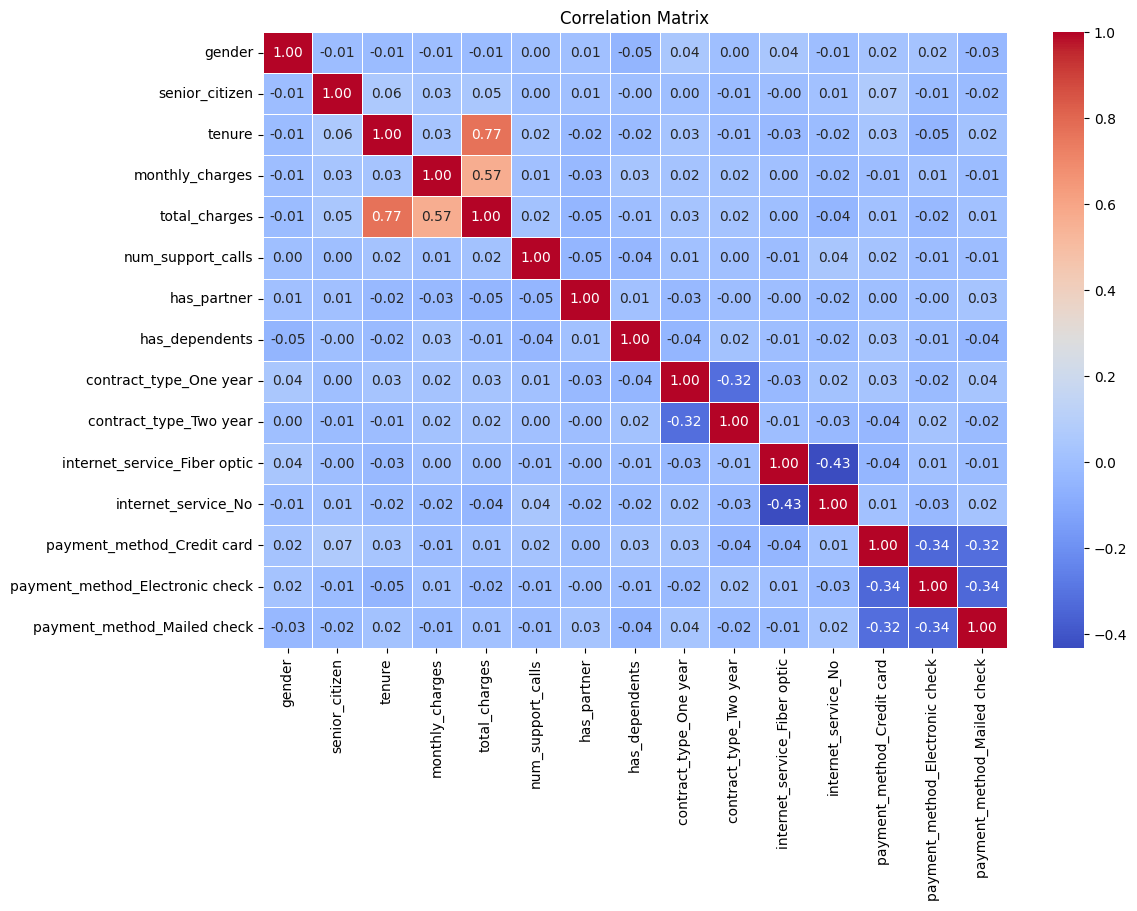

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 8))
numeric_df = X_encoded.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_32132\872911557.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_corr.values, y=churn_corr.index, palette='RdBu')


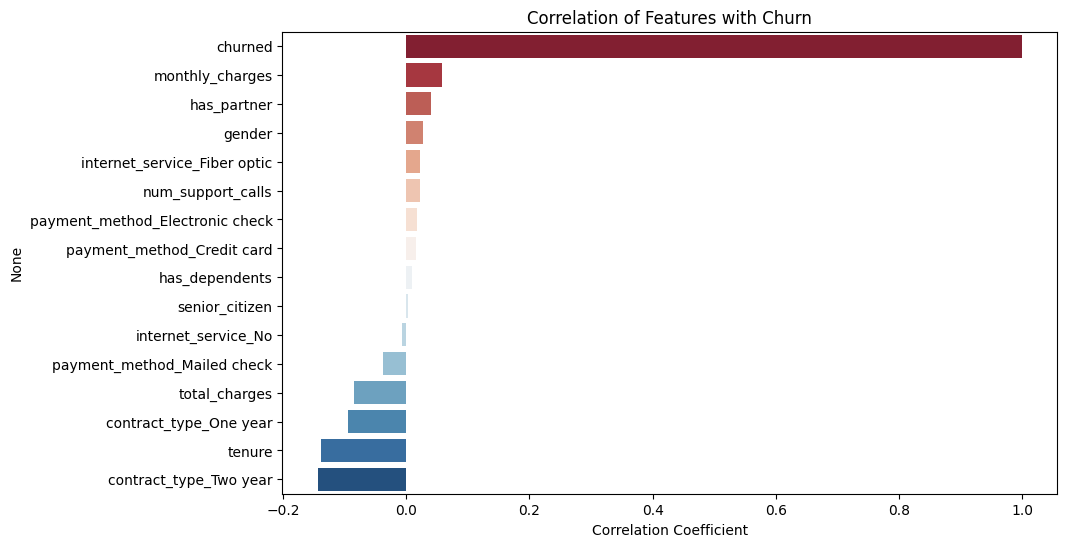

In [96]:
temp_df = X_encoded.copy()
temp_df['churned'] = y

churn_corr = temp_df.corr()['churned'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=churn_corr.values, y=churn_corr.index, palette='RdBu')
plt.title('Correlation of Features with Churn')
plt.xlabel('Correlation Coefficient')
plt.show()

In [97]:
X = X_encoded
y = df['churned']

In [100]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [101]:
print(x_train.shape[0])
print(x_test.shape[0])

1200
300


In [102]:
print(y_train.value_counts(normalize=True)[1])
print(y_test.value_counts(normalize=True)[1])

0.1625
0.16333333333333333


In [103]:
Pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
Pipeline.fit(x_train, y_train)
y_pred = Pipeline.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.66      0.76       251
           1       0.27      0.65      0.38        49

    accuracy                           0.66       300
   macro avg       0.59      0.66      0.57       300
weighted avg       0.80      0.66      0.70       300

[[165  86]
 [ 17  32]]


In [ ]:
classifier = LogisticRegression(max_iter=1000, random_state=42)
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))